In [1]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style("white")
import matplotlib.pyplot as plt
import string
from pickle import dump
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import nltk
from nltk.corpus import stopwords
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aliva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
dataset = pd.read_csv('dataset/emails.csv')
dataset.shape

(5728, 2)

In [3]:
dataset.head() 

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [5]:
dataset.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


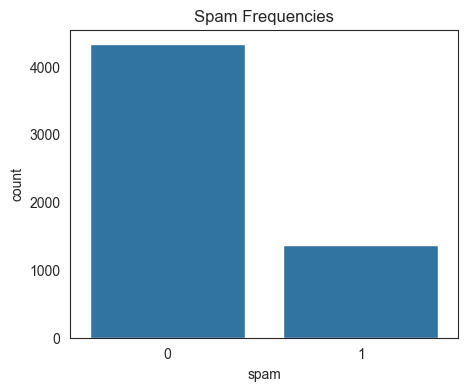

In [10]:
plt.figure(figsize=(5,4), dpi=100)

sns.countplot(x=dataset['spam'])

plt.title("Spam Frequencies")
plt.show()

In [11]:
dataset['spam'].value_counts(normalize=True) * 100

spam
0    75.978929
1    24.021071
Name: proportion, dtype: float64

In [7]:
dataset.isnull().sum()

text    0
spam    0
dtype: int64

In [12]:
dataset.drop_duplicates(inplace=True)

In [14]:
stop_words = set(stopwords.words('english'))

def process(text):
    # remove punctuation
    nopunc = [
        char for char in text
        if char not in string.punctuation
    ]

    nopunc = ''.join(nopunc)

    # remove stopwords
    clean = [
        word for word in nopunc.split()
        if word.lower() not in stop_words
    ]

    return clean

In [15]:
message = CountVectorizer(analyzer=process).fit_transform(dataset['text'])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(message, dataset['spam'], test_size=0.20, random_state=0)

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(analyzer=process)

X = cv.fit_transform(dataset['text'])

In [30]:
model = MultinomialNB()

In [31]:
model.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [32]:
y_pred = model.predict(X_test)


In [33]:
accuracy = accuracy_score(y_test, y_pred)
accuracy * 100

99.20983318700614

In [34]:
classification_report(y_test, y_pred)


'              precision    recall  f1-score   support\n\n           0       1.00      0.99      0.99       870\n           1       0.97      1.00      0.98       269\n\n    accuracy                           0.99      1139\n   macro avg       0.98      0.99      0.99      1139\nweighted avg       0.99      0.99      0.99      1139\n'

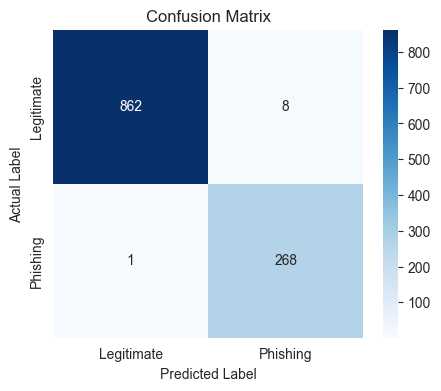

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4), dpi=100)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0.5, 1.5], ['Legitimate', 'Phishing'])
plt.yticks([0.5, 1.5], ['Legitimate', 'Phishing'])

plt.show()

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9920983318700615
Precision: 0.9710144927536232
Recall   : 0.9962825278810409
F1 Score : 0.9834862385321101


In [37]:
pickle.dump(model, open('email_model.pkl', 'wb'))
pickle.dump(cv, open('email_vectorizer.pkl', 'wb'))

In [47]:
test_email = """
Dear Customer,

We detected suspicious activity in your account.

Verify immediately:
http://secure-bank-verification-update.com

Failure to verify within 24 hours may result in account suspension.

"""
vector_input = cv.transform([test_email])

prediction = model.predict(vector_input)[0]
probability = model.predict_proba(vector_input)[0]

print("Prediction:", prediction)
print("Confidence:", round(max(probability) * 100, 2), "%")

if prediction == 1:
    print("⚠️ Phishing / Spam detected")
else:
    print("✅ Legitimate message")

Prediction: 1
Confidence: 100.0 %
⚠️ Phishing / Spam detected


In [49]:
test_email = """
From: alerts@hdfcbank.com
Subject: Transaction Alert – ₹2,500 Debited

Email Body:

Dear Aliva,
INR 2,500 has been debited from your account ending in XXXX on 28 May 2026 at 11:45 AM.
If you did not authorize this transaction, please contact customer support through our official banking app or helpline.

Regards,
Customer Service Team

"""
vector_input = cv.transform([test_email])

prediction = model.predict(vector_input)[0]
probability = model.predict_proba(vector_input)[0]

print("Prediction:", prediction)
print("Confidence:", round(max(probability) * 100, 2), "%")

if prediction == 1:
    print("⚠️ Phishing / Spam detected")
else:
    print("✅ Legitimate message")

Prediction: 1
Confidence: 83.69 %
⚠️ Phishing / Spam detected
